In [ ]:
# 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"   #폰트파일의 위치
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# Excel 데이터를 데이터프레임 변환 
df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

# 누락값(NaN)을 앞 데이터로 채움 (엑셀 양식 병합 부분)
df = df.ffill()

# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')

# 서울에서 경기도로 이동한 인구 데이터 값만 선택 
sr_one = df_seoul.loc['경기도']

# 그림 사이즈 지정(가로 14인치, 세로 5인치)
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(rotation='vertical')

# x, y축 데이터를 plot 함수에 입력 
plt.plot(sr_one.index, sr_one.values)

plt.title('서울 -> 경기 인구 이동')  #차트 제목
plt.xlabel('기간')                  #x축 이름
plt.ylabel('이동 인구수')           #y축 이름

plt.legend(labels=['서울 -> 경기'], loc='best')     #범례 표시

plt.show()  # 변경사항 저장하고 그래프 출력

In [ ]:
# 그림 사이즈 지정(가로 14인치, 세로 5인치)
plt.figure(figsize=(14, 5))

# x축 눈금 라벨 회전하기
plt.xticks(rotation='vertical')

# x, y축 데이터를 plot 함수에 입력 
plt.plot(sr_one.index, sr_one.values)

plt.title('서울 -> 경기 인구 이동')  #차트 제목
plt.xlabel('기간')                  #x축 이름
plt.ylabel('이동 인구수')           #y축 이름

plt.legend(labels=['서울 -> 경기'], loc='best')     #범례 표시

plt.show()  # 변경사항 저장하고 그래프 출력

In [ ]:
# 경기 -> 서울
import pandas as pd
df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')
df
# 1. head() 대략적으로 데이터를 확인
# 2. 데이터의 정보확인 info() describe()
# 3. 결측치 여부 확인
# 결측치가 확인되면 dropna, fillna 선택
df.tail()

In [76]:
# 전출지별 에서 항목이 전국만 있는지 확인하는 방법
df['전출지별'] # 직접 확인하기에는 중간에 생략된부분을 확인 할수가 없다.
df['전출지별'].value_counts() # 그래서 해당 컬럼의 종목의 갯수와 목록을 조회

전출지별
전국         18
서울특별시      18
부산광역시      18
강원도        18
대구광역시      18
인천광역시      18
광주광역시      18
대전광역시      18
울산광역시      18
세종특별자치시    18
경기도        18
전라남도       18
충청북도       18
충청남도       18
전라북도       18
경상남도       18
경상북도       18
제주특별자치도    18
전출지별        1
Name: count, dtype: int64

In [ ]:
# 결과적으로 전국외에도 다른 값들이 있다는 것을 확인, 기술적 결함으로 인한 결측치는 아니지만
# 빈칸을 해당지역들로 채우면 된다는 것으로 판단
    # 전국, 서울특별시, 부산광역시, ... 이 지역의 범위를 어떻게 알아내지? ^
df['전출지별'] = df['전출지별'].ffill()
df
# -> 문자열이고 병합된 컬럼의 정보가 na로 표기되어서  앞의 문자열로 대처처리

In [ ]:
df.info()

In [ ]:
# 결측치 확인, 데이터프레임 전체 결측치 개수
df.isna().sum().values.sum()

# df.isna() → True/False 데이터프레임
# .sum() → 열별 결측치 개수  True = 1 / False = 0
# .values → 순수 숫자 배열 - 행별 결측치 여부및 갯수가 표기된 숫자 리스트 
# .sum() → 전체 합계 → 전체 결측치 개수 - 행별 모든 결측치 갯수 더하기

In [ ]:
# 문자형 숫자 -> 숫자로 변경하는데,  변경불가능한 데이터는 결측치로 대처
pd.to_numeric(df.loc[1:,'1970'],errors='ignore')

In [ ]:
mask = (df['전출지별'] == '경기도') & (df['전입지별'] == '서울특별시')
df2 = df[mask]

In [72]:
df2.isna().sum().values.sum()
df3 = df2.iloc[:,2:]
df3

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
164,95388,95423,90470,107177,107518,207641,144524,154021,164771,168188,...,323515,317952,285963,272407,254175,246464,249701,239557,234357,234448


In [73]:
import matplotlib.pyplot as plt
# 2차원 데이터임을 확인
df2.values.shape

# 펼쳐서 1차원데이터로 변환
df2.values.flatten()

array(['경기도', '서울특별시', 95388, 95423, 90470, 107177, 107518, 207641,
       144524, 154021, 164771, 168188, 231651, 187880, 196664, 230913,
       227920, 226354, 233258, 307770, 410274, 345173, 282914, 256270,
       253605, 256049, 258897, 262893, 290660, 298306, 276685, 340653,
       312616, 319738, 321390, 325065, 289817, 311892, 357818, 336648,
       323515, 317952, 285963, 272407, 254175, 246464, 249701, 239557,
       234357, 234448], dtype=object)

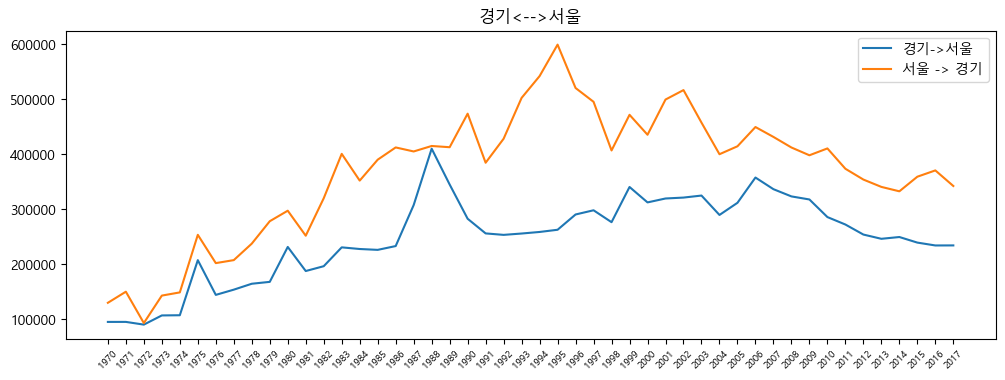

In [75]:
plt.figure(figsize =(12,4))
plt.title('경기<-->서울')

plt.plot(df3.columns, df3.values.flatten(),label = '경기 -> 서울') # 경기 -> 서울
plt.plot(sr_one.index, sr_one.values,label = '서울 -> 경기') # 서울 -> 경기

plt.legend(labels = ['경기->서울','서울 -> 경기'],loc = 'best')

plt.xticks(rotation = 45, fontsize = 7)
plt.show()

In [ ]:
# 1991 ~ 1995 데이터를  추출해서 gpt를 동해 인구 이동 추론

In [91]:
# 1991 ~ 1995 데이터 추출
import pandas as pd
df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')
print(df.loc[:,'1991':'1995'])

print(sr_one['1991':'1995'])

         1991      1992      1993      1994      1995
0    이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)
1     8980841   9031576   8807058   8791714   9073069
2     2437238   2395814   2259333   2240086   2165332
3      741748    771852    708358    668188    676037
4      525249    558826    524585    545677    534013
..        ...       ...       ...       ...       ...
320       547       593       517       532       562
321      1474      1565      1801      1415      1413
322       683       692       712       675       718
323      1385      1470      1569      1609      1547
324     53135     56853     55002     59094     65003

[325 rows x 5 columns]
1991    384714
1992    428344
1993    502584
1994    542204
1995    599411
Name: 경기도, dtype: object


In [ ]:
# 너는 데이터 분석가
# 우리는 다음데이터를 통해서 어떤 사회현상이 일어났길래 저렇게 되었는지 과거정보를 분석해서 원인을 도출해줘
# 과정을 순차적으로 보여주고 참고한 정보의 구체적인 출처도 남겨줘
# 1. 경기에서 서울로 유입된 인구 수
#          1991      1992      1993      1994      1995
# 0    이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)
# 1     8980841   9031576   8807058   8791714   9073069
# 2     2437238   2395814   2259333   2240086   2165332
# 3      741748    771852    708358    668188    676037
# 4      525249    558826    524585    545677    534013
# ..        ...       ...       ...       ...       ...
# 320       547       593       517       532       562
# 321      1474      1565      1801      1415      1413
# 322       683       692       712       675       718
# 323      1385      1470      1569      1609      1547
# 324     53135     56853     55002     59094     65003
# 2. 서울에서 경기로 유입된 년도별 인구수
# 1991    384714
# 1992    428344
# 1993    502584
# 1994    542204
# 1995    599411
# 3. 시각화로 확인했을때 서울에서 경기도로 이동한 인구가 급격히 증가하는 패턴을 보이는데
# 해당 이유에 대해서 각종 자료들을 참고해줘 